# Example 6: Maximum likelihood filtering of the ionic current power spectrum of liquid NaCl

This example shows how to use *sportran* to compute the ionic conductivity of a classical MD simulation of molten NaCl. Incidentally, the same code can be used to filter the whole infra-red spectrum.

For reference: [Pegolo et al., J. Chem. Phys. 162, 064111 (2025)](https://doi.org/10.1063/5.0249677)

In [23]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import json

try:
    import sportran as st
except ImportError:
    from sys import path

    path.append("..")
    import sportran as st

c = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## 1. Load trajectory

Read the ionic current from a simple column-formatted file and some additional information (e.g. temperature and supercell volume) from a JSON file.

In [26]:
ionic_flux = np.loadtxt("data/CsF/ionic_flux.txt")

with open("data/CsF/thermo.json") as f:
    thermo = json.load(f)

## 2. Electric Current

Instantiate an `ElectricCurrent` object from the trajectory.

In [32]:
DT_FS = 2.0  # time step [fs]
TEMPERATURE = thermo["Temperature"]  # temperature [K]
VOLUME = thermo["Volume"]  # volume [A^3]
print("T = {:.2f} K".format(TEMPERATURE))
print("V = {:.2f} A^3".format(VOLUME))

j = st.ElectricCurrent(
    ionic_flux,
    UNITS="metal",
    DT_FS=DT_FS,
    TEMPERATURE=TEMPERATURE,
    VOLUME=VOLUME,
)

T = 1221.56 K
V = 20193.55 A^3
Using single component code.


Text(0, 0.5, '$J_c$ [e A/ps]')

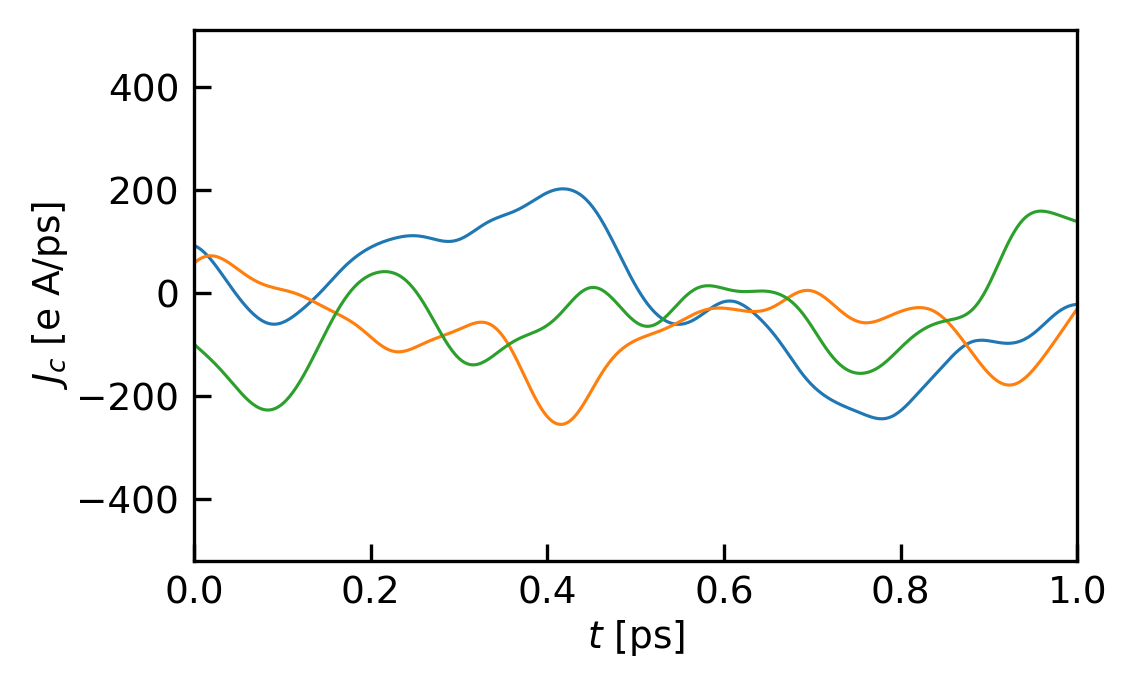

In [40]:
# trajectory
f, ax = plt.subplots()
ax.plot(j.timeseries() / 1000.0, j.traj)
ax.set_xlim([0, 1.0])
ax.set_xlabel(r"$t$ [ps]")
ax.set_ylabel(r"$J_c$ [e A/ps]")

Compute the **periodogram** $\mathcal{S}_k$ and filter it for visualization.

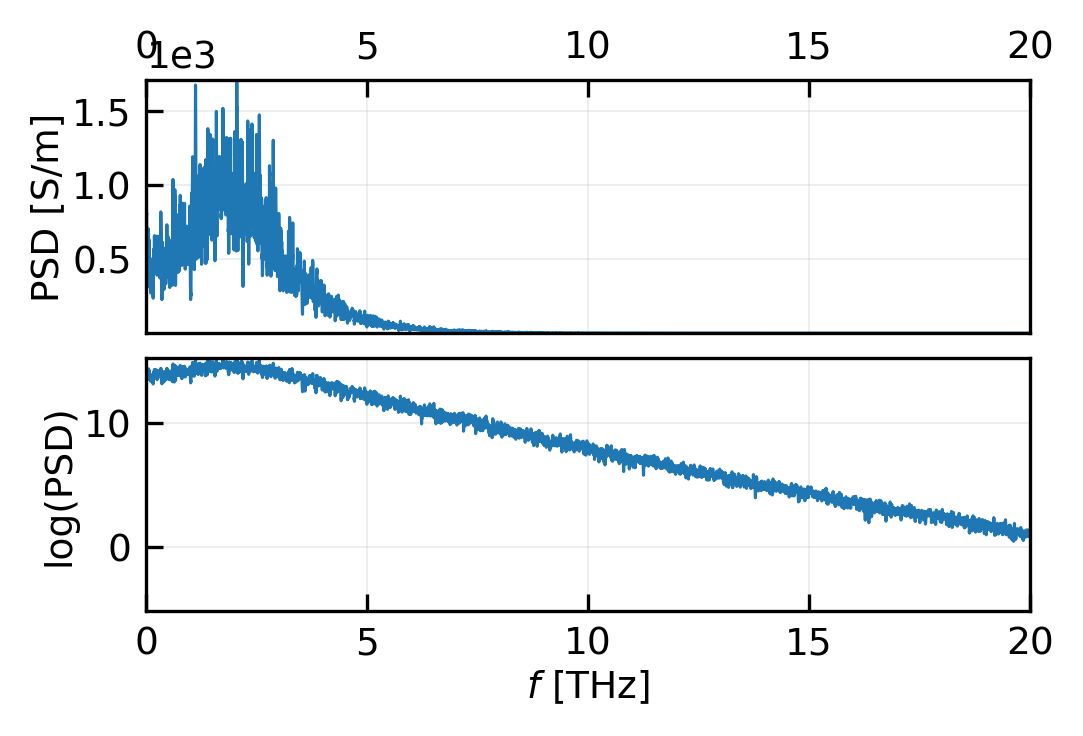

In [49]:
# Periodogram with given filtering window width
axes = j.plot_periodogram(PSD_FILTER_W=0.01, kappa_units=True)
for ax in axes:
    ax.set_xlim([0, 20])

## 3. Resampling

If the Nyquist frequency is very high (*i.e.* the sampling time is very small), such that the log-spectrum goes to low values, you may want *resample* your time series, in order to reduce the maximum frequency to $f^*$.
Before performing that operation, the time series is automatically filtered to reduce the amount of aliasing introduced. Ideally you do not want to go too low in $f^*$, because the statistical error may increase. In an intermediate region the results should not change. 

To perform resampling you can choose the resampling frequency $f^*$ (`fstar_THz`) or the resampling step (`TSKIP`). If you choose $f^*$, the code will try to find the closest value allowed.
The resulting $\rm PSD$ can be visualized to ensure that the low-frequency region was not affected by this operations

Using single component code.
-----------------------------------------------------
  RESAMPLE TIME SERIES
-----------------------------------------------------
 Original Nyquist freq  f_Ny =     250.00000 THz
 Resampling freq          f* =      10.00000 THz
 Sampling time         TSKIP =            25 steps
                             =        50.000 fs
 Original  n. of frequencies =        100001
 Resampled n. of frequencies =          4001
 PSD      @cutoff  (pre-filter&sample) ~   2750.28470
                  (post-filter&sample) ~   2065.56528
 log(PSD) @cutoff  (pre-filter&sample) ~      7.66062
                  (post-filter&sample) ~      7.58979
 min(PSD)          (pre-filter&sample) =      0.00542
 min(PSD)         (post-filter&sample) =    220.03068
 % of original PSD Power f<f* (pre-filter&sample)  = 99.944 %
-----------------------------------------------------



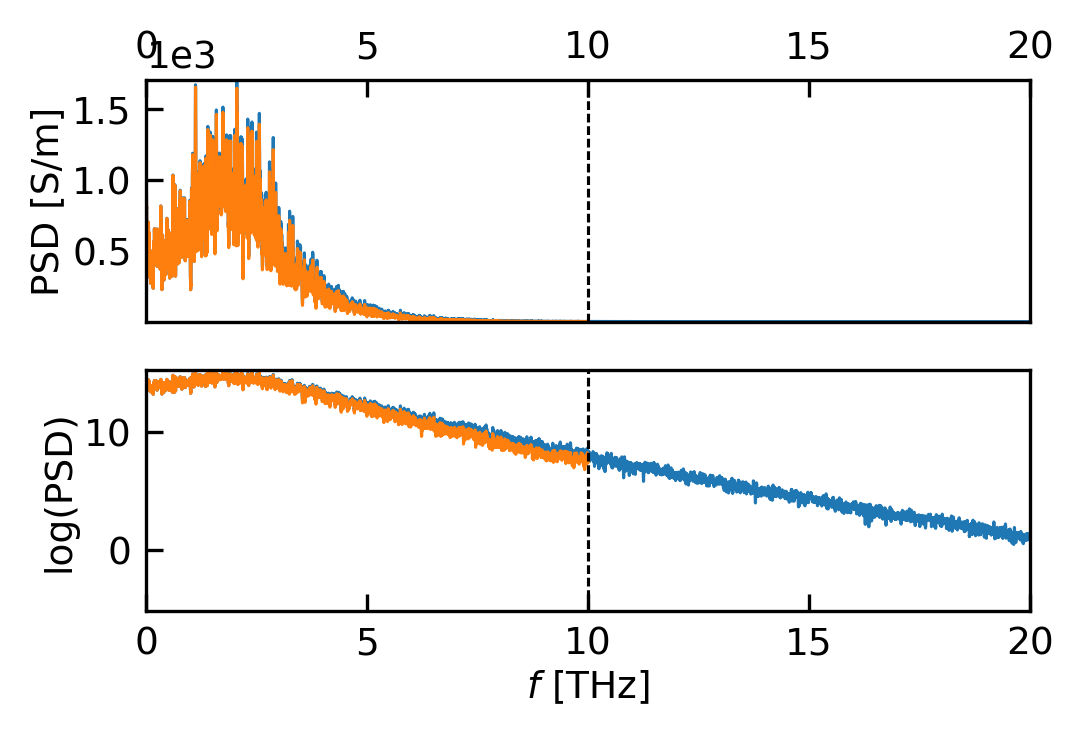

In [53]:
FSTAR_THZ = 10.0
jf, axes = j.resample(fstar_THz=FSTAR_THZ, plot=True, freq_units="thz")
for ax in axes:
    ax.set_xlim([0, 20])

## 4. Maximum-likelhood filter

Filter the periodogram with a cubinc spline model optimized via maximum likelihood.

In [86]:
from scipy.interpolate import CubicSpline


def chi2_model(x, y):
    """
    Fit a cubic spline to the data and return the chi2 value.
    """
    # Mirror the x values to enforce even parity
    x_mirror = np.concatenate([-x[::-1], x[1:]])
    y_mirror = np.concatenate([y[::-1], y[1:]])
    return CubicSpline(x_mirror, y_mirror, bc_type="clamped")

In [99]:
jf.maxlike_estimate(model=chi2_model, likelihood="chisquare", n_parameters="aic")

MaxLikeFilter Initialization
Maximum-likelihood estimation with n_parameters = aic
Optimal number of parameters between 3 and 40 chosen by AIC
n_parameters = 3
Spline nodes are equispaced from 0 to the Nyquist frequency.
AIC: -61099.69575408744; Steps since last AIC update: 0
n_parameters = 4
Spline nodes are equispaced from 0 to the Nyquist frequency.
AIC: -61003.67240652038; Steps since last AIC update: 0
n_parameters = 5
Spline nodes are equispaced from 0 to the Nyquist frequency.
AIC: -60791.61538546879; Steps since last AIC update: 0
n_parameters = 6
Spline nodes are equispaced from 0 to the Nyquist frequency.
AIC: -60769.6127503083; Steps since last AIC update: 0
n_parameters = 7
Spline nodes are equispaced from 0 to the Nyquist frequency.
AIC: -60768.28499093361; Steps since last AIC update: 0
n_parameters = 8
Spline nodes are equispaced from 0 to the Nyquist frequency.
AIC: -60769.10742397417; Steps since last AIC update: 1
n_parameters = 9
Spline nodes are equispaced from 0 to

Text(0, 0.5, '$\\sigma$ [S/cm]')

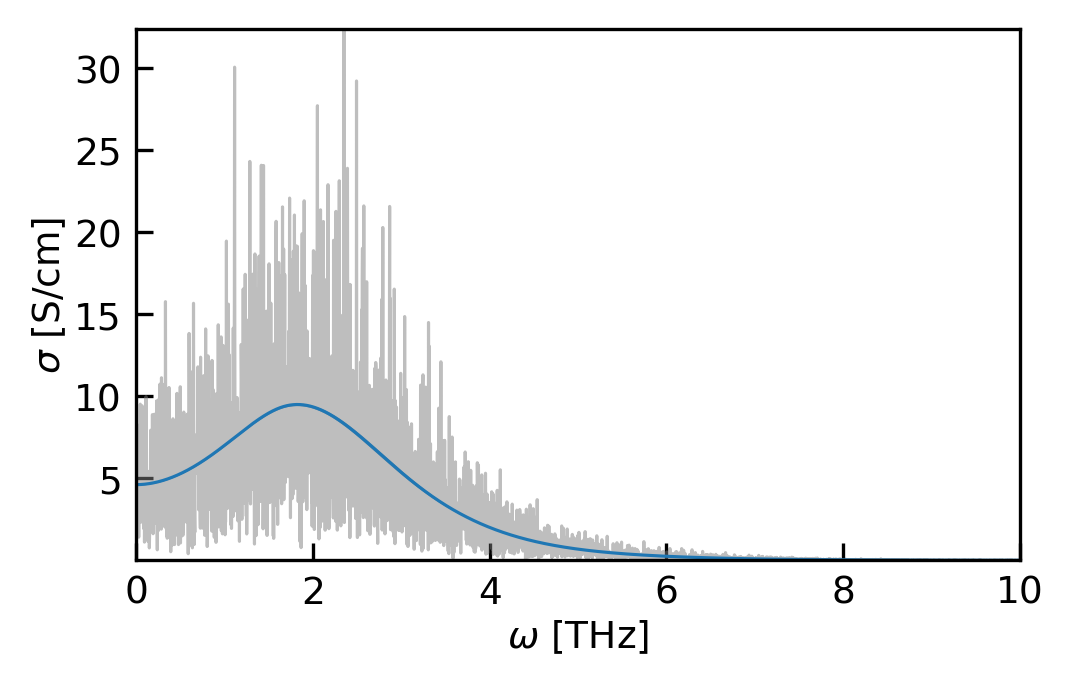

In [108]:
fig, ax = plt.subplots()
ax.plot(
    jf.freqs_THz,
    jf.KAPPA_SCALE / 200 * jf.psd,
    label="PSD",
    color="tab:grey",
    alpha=0.5,
)
ax.plot(
    jf.freqs_THz,
    jf.KAPPA_SCALE / 200 * jf.maxlike.NLL_mean,
    label="NLL filtered",
    color="tab:blue",
)
ax.fill_between(
    jf.freqs_THz,
    jf.KAPPA_SCALE / 200 * (jf.maxlike.NLL_mean - jf.maxlike.NLL_std),
    jf.KAPPA_SCALE / 200 * (jf.maxlike.NLL_mean + jf.maxlike.NLL_std),
    color="tab:blue",
    alpha=0.8,
)

ax.set_xlabel(r"$\omega$ [THz]")
ax.set_ylabel(r"$\sigma$ [S/cm]")